In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")



In [5]:
# Load dataset
loan_df = pd.read_csv("prosperLoanData.csv")

loan_df.shape

(113937, 81)

In [6]:
loan_df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [7]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

In [8]:
# Select important columns for the analysis
selected_columns = [
    "LoanOriginalAmount",
    "BorrowerRate",
    "LoanStatus",
    "IncomeRange",
    "EmploymentStatus",
    "CreditScoreRangeUpper",
    "DebtToIncomeRatio"
]

loan_df = loan_df[selected_columns].copy()

In [9]:
# Check missing values
loan_df.isnull().sum()

LoanOriginalAmount          0
BorrowerRate                0
LoanStatus                  0
IncomeRange                 0
EmploymentStatus         2255
CreditScoreRangeUpper     591
DebtToIncomeRatio        8554
dtype: int64

In [10]:
# Drop rows with missing values in important columns
loan_df = loan_df.dropna(subset=[
    "LoanOriginalAmount",
    "BorrowerRate",
    "LoanStatus",
    "IncomeRange",
    "CreditScoreRangeUpper"
])

In [11]:
# Remove invalid income values
loan_df = loan_df[
    ~loan_df["IncomeRange"].isin(["Not displayed", "Not employed", "$0"])
]

In [12]:
# Convert BorrowerRate to percentage
loan_df["BorrowerRatePercent"] = loan_df["BorrowerRate"] * 100

In [13]:
# Define income order
income_order = [
    "$1-24,999",
    "$25,000-49,999",
    "$50,000-74,999",
    "$75,000-99,999",
    "$100,000+"
]

loan_df["IncomeRange"] = pd.Categorical(
    loan_df["IncomeRange"],
    categories=income_order,
    ordered=True
)

In [14]:
def add_title_labels(title, xlabel, ylabel):
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()

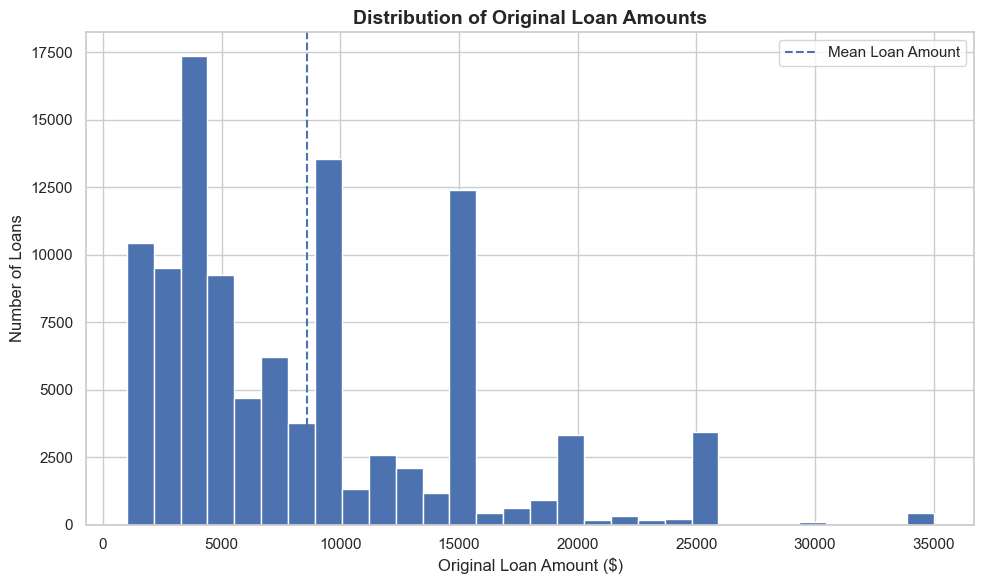

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    data=loan_df,
    x="LoanOriginalAmount",
    bins=30
)

plt.axvline(
    loan_df["LoanOriginalAmount"].mean(),
    linestyle="--",
    label="Mean Loan Amount"
)

add_title_labels(
    "Distribution of Original Loan Amounts",
    "Original Loan Amount ($)",
    "Number of Loans"
)

plt.legend()
plt.show()

# 1. Histogram – Distribution of Loan Amounts

## Question
What is the distribution of loan amounts in the Prosper dataset?

## Visualization
A histogram was created to examine the distribution of the original loan amounts.

## Observation
The distribution of loan amounts is right-skewed, indicating that most borrowers receive loans in the lower to medium range, while relatively few borrowers receive very large loans. This suggests that Prosper loans are primarily used for moderate financing needs.

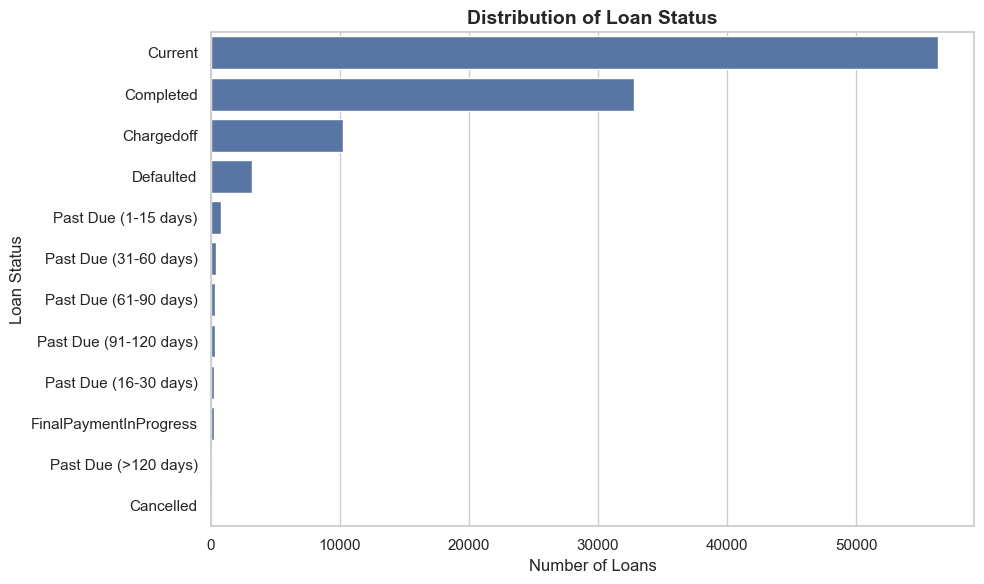

In [16]:
plt.figure(figsize=(10, 6))

status_order = loan_df["LoanStatus"].value_counts().index

sns.countplot(
    data=loan_df,
    y="LoanStatus",
    order=status_order
)

add_title_labels(
    "Distribution of Loan Status",
    "Number of Loans",
    "Loan Status"
)

plt.show()

# 2. Count Plot – Loan Status

## Question
Which loan statuses occur most frequently in the dataset?

## Visualization
A count plot was used to display the frequency of each loan status category.

## Observation
Current and Completed loans represent the largest groups in the dataset. This indicates that most loans are either actively being repaid or have been successfully completed. Other statuses occur much less frequently.

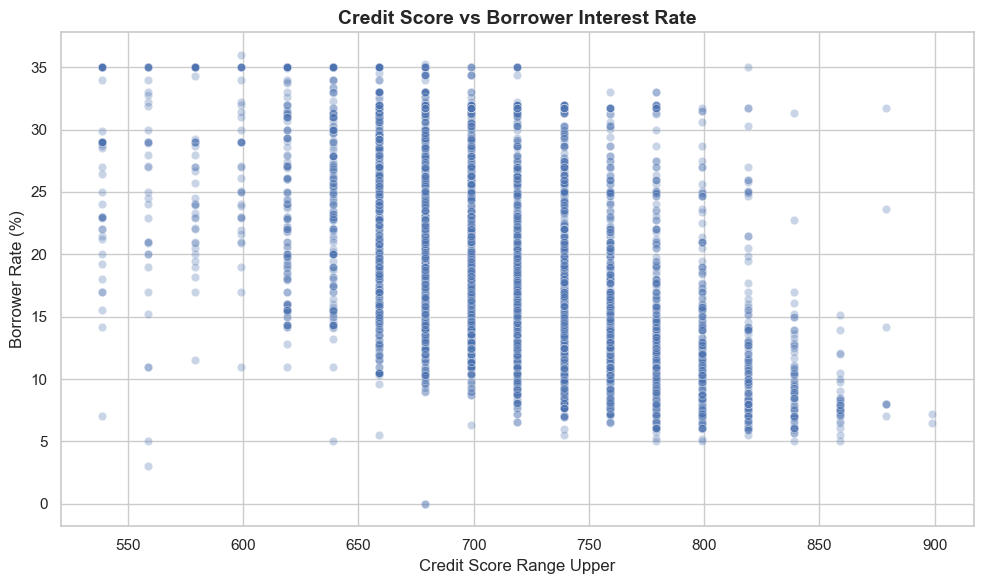

In [17]:
plt.figure(figsize=(10, 6))

sample_df = loan_df.sample(5000, random_state=42)

sns.scatterplot(
    data=sample_df,
    x="CreditScoreRangeUpper",
    y="BorrowerRatePercent",
    alpha=0.3
)

add_title_labels(
    "Credit Score vs Borrower Interest Rate",
    "Credit Score Range Upper",
    "Borrower Rate (%)"
)

plt.show()

# 3. Scatter Plot – Credit Score vs Borrower Rate

## Question
Is there a relationship between borrower credit score and interest rate?

## Visualization
A scatter plot was created using CreditScoreRangeUpper and BorrowerRate.

## Observation
A negative relationship is visible between credit score and borrower rate. Borrowers with higher credit scores generally receive lower interest rates. This pattern suggests that creditworthiness plays an important role in determining borrowing costs.

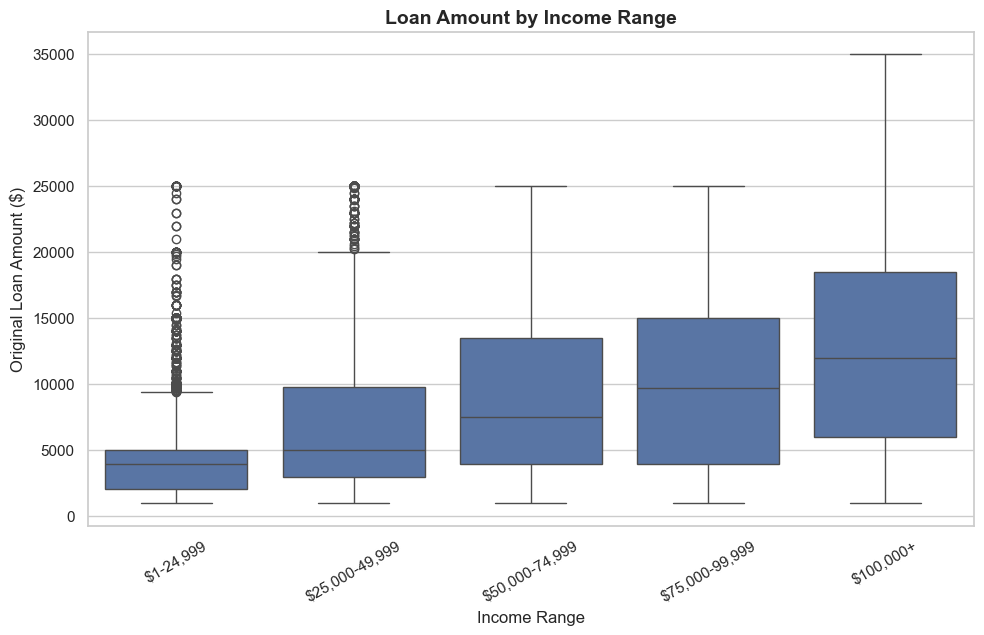

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=loan_df,
    x="IncomeRange",
    y="LoanOriginalAmount",
    order=income_order
)

add_title_labels(
    "Loan Amount by Income Range",
    "Income Range",
    "Original Loan Amount ($)"
)

plt.xticks(rotation=30)
plt.show()

# 4. Box Plot – Income Range vs Loan Amount

## Question
Does borrower income influence the amount of money borrowed?

## Visualization
A box plot was used to compare loan amounts across income ranges.

## Observation
Higher-income borrowers tend to receive larger loans. The median loan amount increases across income categories, indicating that income level is an important factor in determining borrowing capacity and loan approval amounts.

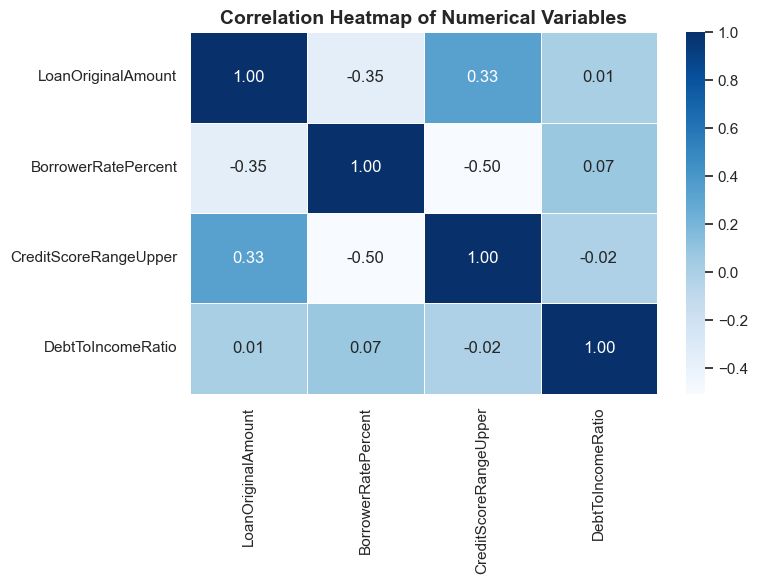

In [19]:
numeric_features = [
    "LoanOriginalAmount",
    "BorrowerRatePercent",
    "CreditScoreRangeUpper",
    "DebtToIncomeRatio"
]

corr_matrix = loan_df[numeric_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

add_title_labels(
    "Correlation Heatmap of Numerical Variables",
    "",
    ""
)

plt.show()

# 5. Heatmap – Correlation Between Numerical Variables

## Question
What relationships exist among the main numerical variables in the dataset?

## Visualization
A correlation heatmap was created for loan amount, borrower rate, credit score, and debt-to-income ratio.

## Observation
The strongest relationship observed is a negative correlation between credit score and borrower rate. Borrowers with stronger credit profiles generally receive lower interest rates. Other variables show weaker relationships but still provide useful insights into borrower behavior.

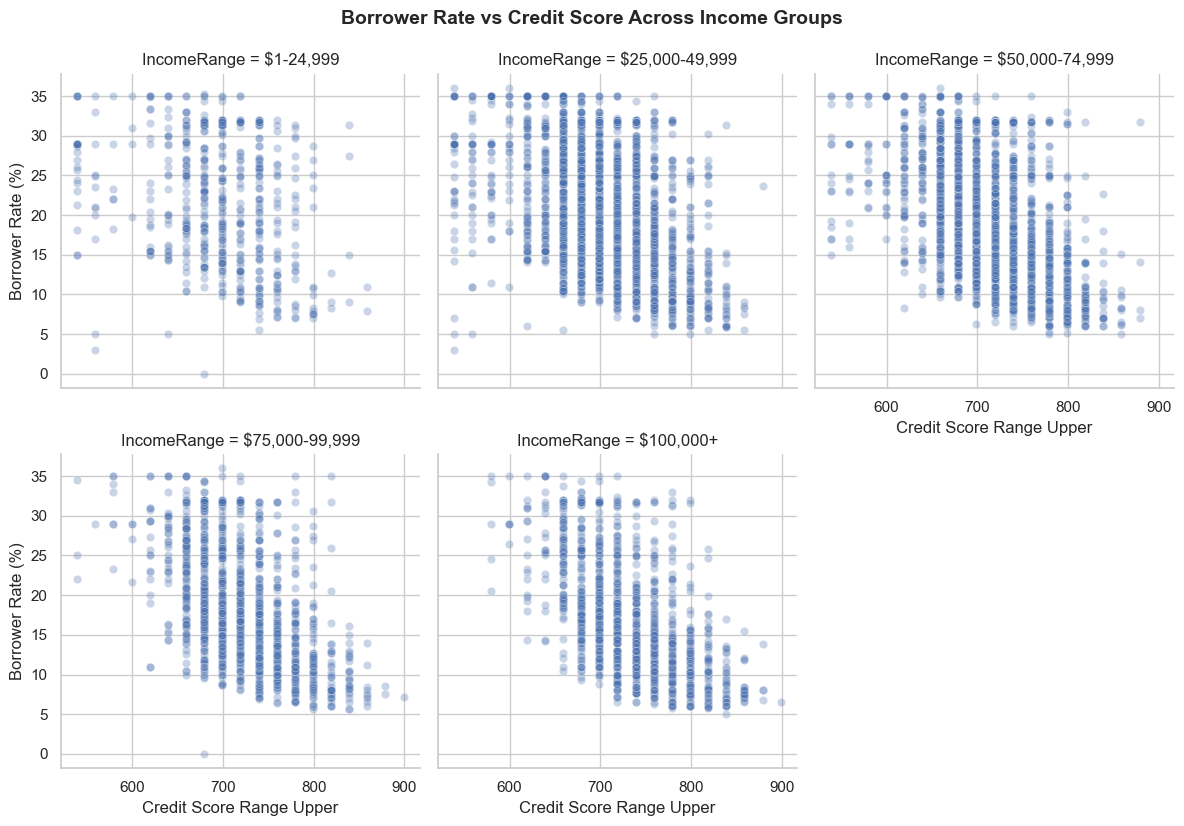

In [20]:
facet_sample = loan_df.sample(8000, random_state=42)

g = sns.FacetGrid(
    data=facet_sample,
    col="IncomeRange",
    col_wrap=3,
    height=4,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="CreditScoreRangeUpper",
    y="BorrowerRatePercent",
    alpha=0.3
)

g.set_axis_labels(
    "Credit Score Range Upper",
    "Borrower Rate (%)"
)

g.fig.suptitle(
    "Borrower Rate vs Credit Score Across Income Groups",
    fontsize=14,
    weight="bold",
    y=1.03
)

plt.show()

# 6. Facet Plot – Credit Score and Borrower Rate Across Income Groups

## Question
Does the relationship between credit score and borrower rate differ across income groups?

## Visualization
A faceted scatter plot was created with separate panels for each income range.

## Observation
The negative relationship between credit score and borrower rate appears consistently across all income groups. However, borrowers in higher income categories tend to be concentrated in regions associated with lower interest rates, suggesting that both income and credit score contribute to favorable loan terms.

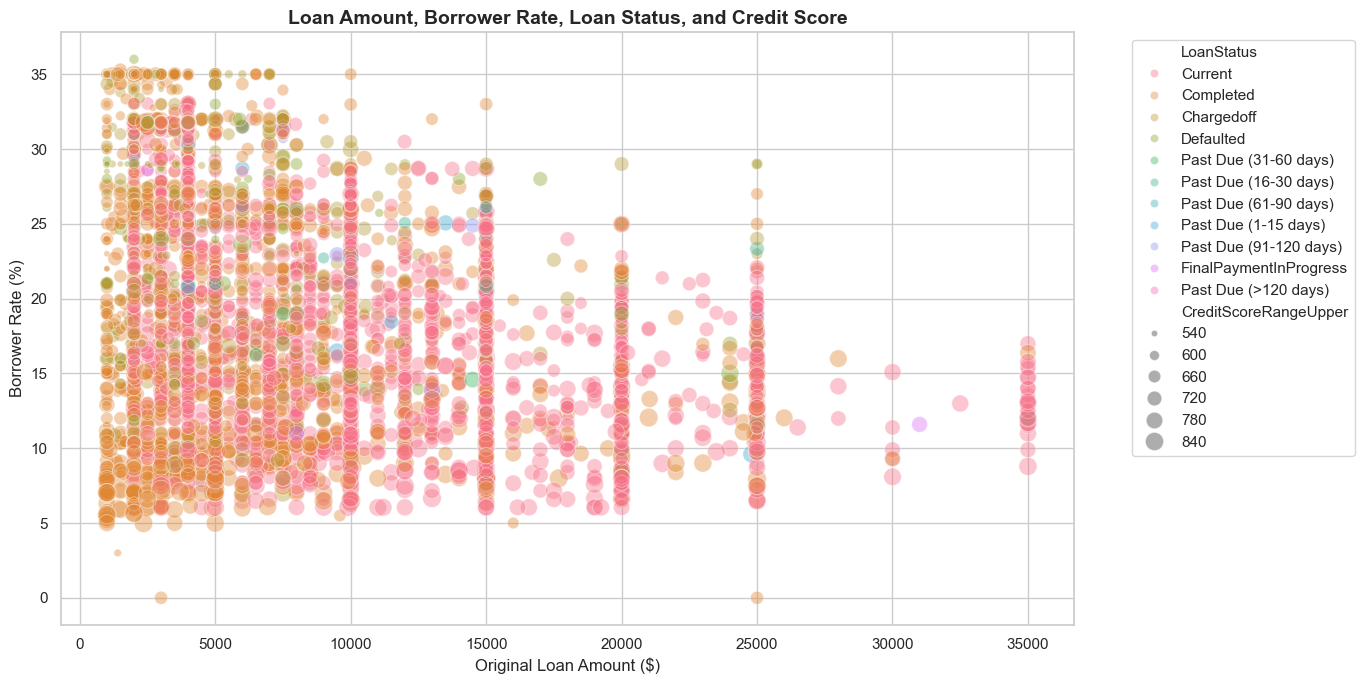

In [21]:
multi_sample = loan_df.sample(5000, random_state=42)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=multi_sample,
    x="LoanOriginalAmount",
    y="BorrowerRatePercent",
    hue="LoanStatus",
    size="CreditScoreRangeUpper",
    sizes=(20, 200),
    alpha=0.4
)

add_title_labels(
    "Loan Amount, Borrower Rate, Loan Status, and Credit Score",
    "Original Loan Amount ($)",
    "Borrower Rate (%)"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

# 7. Multivariate Scatter Plot – Loan Amount, Borrower Rate, Loan Status, and Credit Score

## Question
How do loan amount, interest rate, loan status, and credit score interact with one another?

## Visualization
A scatter plot was created with loan amount on the x-axis, borrower rate on the y-axis, loan status represented by color, and credit score represented by marker size.

## Observation
The visualization shows that borrowers with larger credit scores generally appear in lower-interest-rate regions of the plot. Loan status categories overlap considerably, but the chart provides a comprehensive view of how multiple borrower characteristics and loan outcomes interact simultaneously.

Part II: Explanatory Analysis

Use only polished final plots.


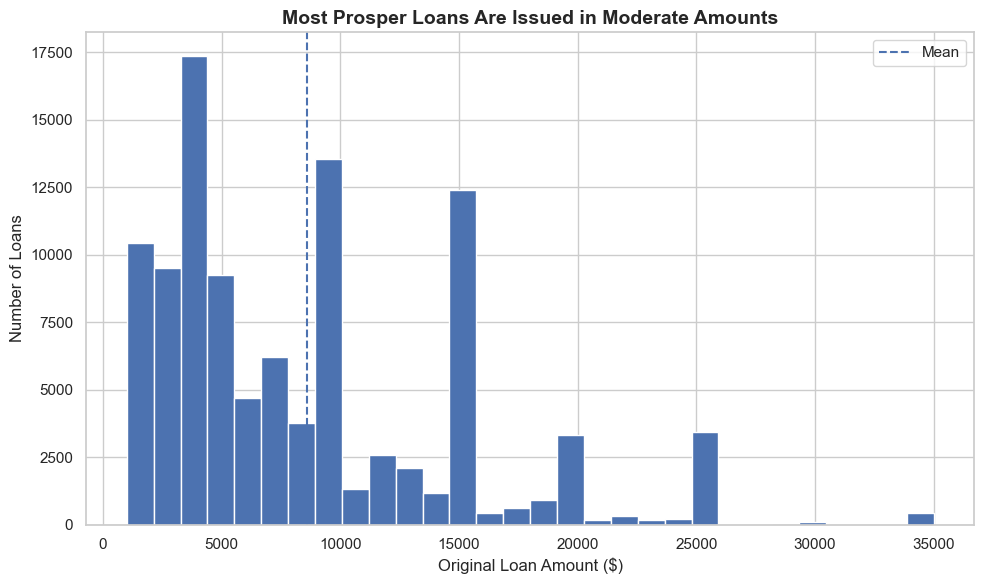

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    data=loan_df,
    x="LoanOriginalAmount",
    bins=30
)

plt.axvline(
    loan_df["LoanOriginalAmount"].mean(),
    linestyle="--",
    label="Mean"
)

add_title_labels(
    "Most Prosper Loans Are Issued in Moderate Amounts",
    "Original Loan Amount ($)",
    "Number of Loans"
)

plt.legend()
plt.show()

Most Prosper loans are issued in moderate amounts, with the majority falling below $15,000. The right-skewed distribution indicates that larger loans are less common.

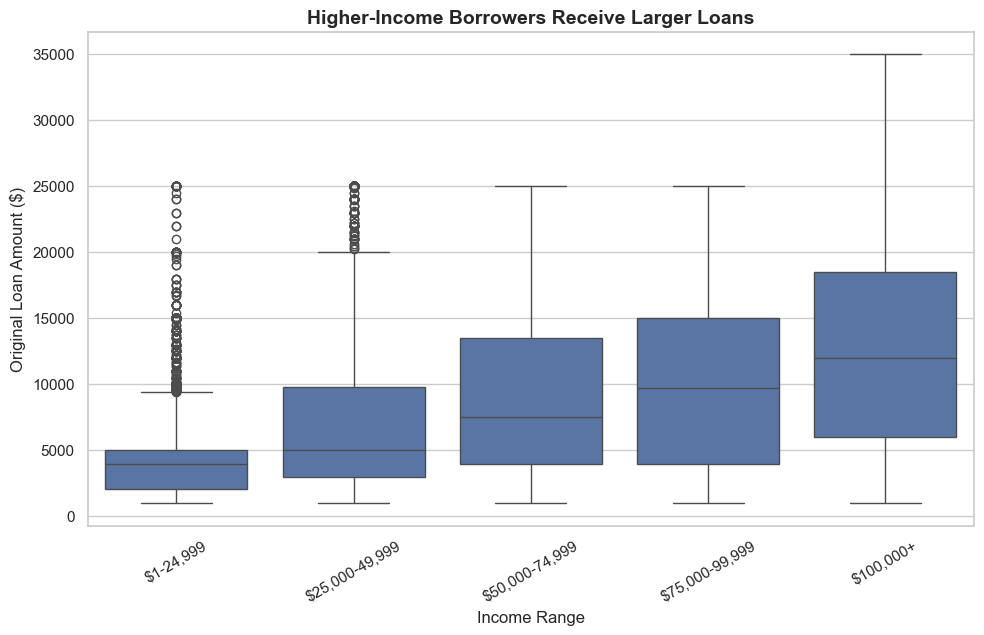

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=loan_df,
    x="IncomeRange",
    y="LoanOriginalAmount",
    order=income_order
)

add_title_labels(
    "Higher-Income Borrowers Receive Larger Loans",
    "Income Range",
    "Original Loan Amount ($)"
)

plt.xticks(rotation=30)
plt.show()

Higher-income borrowers consistently receive larger loans. The median loan amount increases substantially across income brackets, demonstrating that income is a strong predictor of borrowing capacity.

/Users/abdelhadi/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/abdelhadi/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/abdelhadi/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


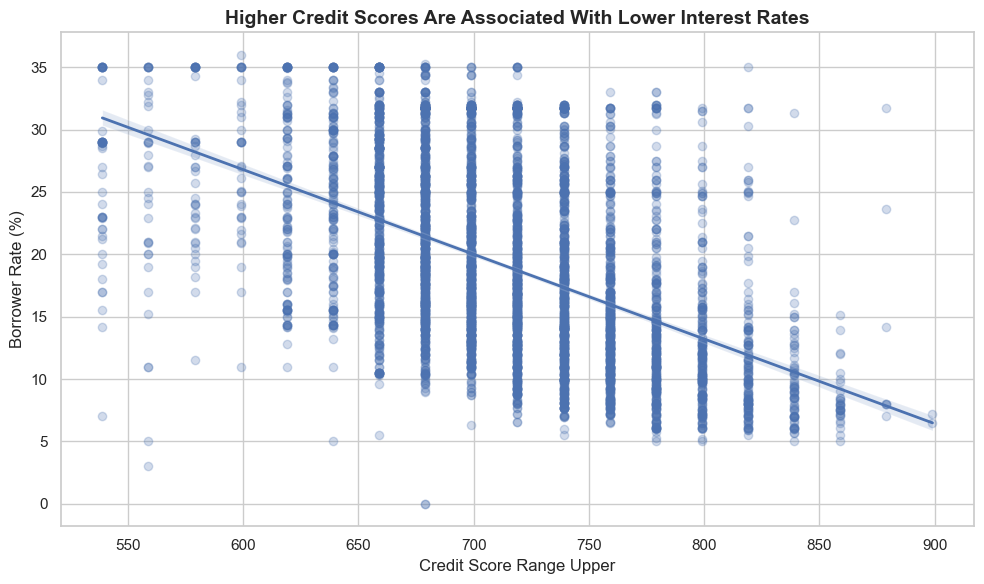

In [24]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=sample_df,
    x="CreditScoreRangeUpper",
    y="BorrowerRatePercent",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

add_title_labels(
    "Higher Credit Scores Are Associated With Lower Interest Rates",
    "Credit Score Range Upper",
    "Borrower Rate (%)"
)

plt.show()

A strong negative relationship exists between credit score and borrower interest rate. Borrowers with higher credit scores benefit from significantly lower interest rates, reflecting the financial risk premium applied to lower-credit borrowers.

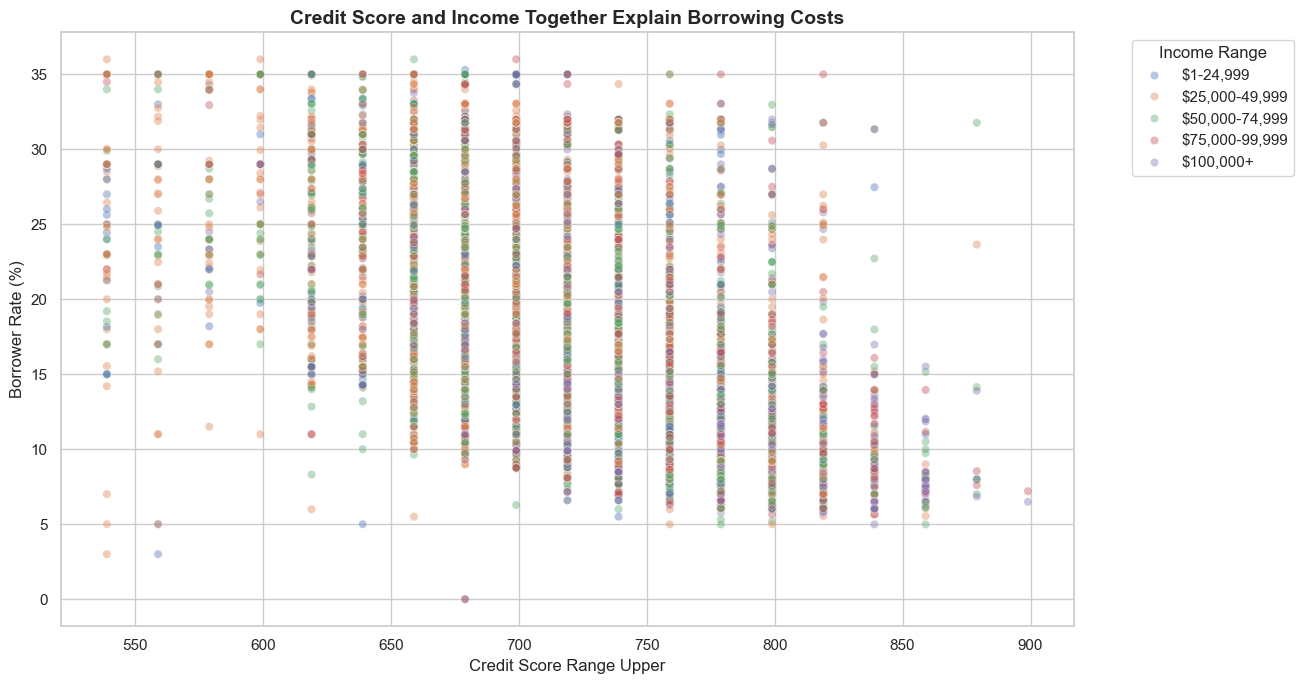

In [25]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=facet_sample,
    x="CreditScoreRangeUpper",
    y="BorrowerRatePercent",
    hue="IncomeRange",
    alpha=0.4
)

add_title_labels(
    "Credit Score and Income Together Explain Borrowing Costs",
    "Credit Score Range Upper",
    "Borrower Rate (%)"
)

plt.legend(
    title="Income Range",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

Credit score and income together explain borrowing costs. While all income groups show the credit score-rate relationship, higher-income borrowers are more concentrated in the favorable (low rate) region of the plot, indicating that both factors combine to determine loan terms.

# Conclusions
This investigation explored factors associated with loan amounts and borrower interest rates in the Prosper Loan Dataset.

Several important findings emerged from the analysis:

1. Most Prosper loans are issued in moderate amounts, with relatively few very large loans.
2. Current and Completed loans represent the majority of loan records.
3. Higher-income borrowers generally receive larger loans.
4. Credit score has a strong negative relationship with borrower interest rate.
5. Borrowers with both high incomes and strong credit scores tend to receive the most favorable loan terms.

Overall, credit score appears to be the strongest predictor of borrowing cost, while income plays an important role in determining loan size. These findings provide a foundation for the explanatory analysis, which focuses on how borrower financial characteristics influence loan outcomes and borrowing conditions.